# 2025/03/20 - Kraken2 PFP16 results

## Summary

In this notebook, we will try to obtain a preliminary view of the diversity that we might find in our samples. We used the PlusPFP16 database, which in theory contains fungi, protist, plants, bacteria, etc. Therefore, although it is not the best version of the database, we can expect:

1. To find a large amount of host RNA. 
2. To find a global overview of the diversity of different domains of life within each sample.
3. To find a global overview of the diversity of different bacteria within each sample.
4. To check whether some of Marcos hits are also detected by Kraken2.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from seaborn import objects as so
import tqdm
import taxoniq
# sns.set_context("paper")

## Reading data

Our data is stored as summaries of Kraken2 classification. Loading the whole Kraken2 classification requires too much space, so we ran a script that summarizes the number of reads per sample by the classification in the first four terms of the phylogenetic tree.

In [16]:
with open('../results/2025-03-12-kraken2-pfp16-run/.input') as f:
    index = list(map(lambda x: x.strip(), f.readlines()))

In [17]:
hits = []
counts = []
for file in tqdm.tqdm(index):
    hits_tmp = pd.read_csv(f'../results/2025-03-12-kraken2-pfp16-run/{file}.hits.csv', index_col=0)
    hits.append(hits_tmp)
    
hits = pd.concat(hits).reset_index()
hits['library'] = hits['library'].apply(lambda x: "PV{:03d}".format(int(x.replace("PV", ""))))
hits

100%|██████████| 247/247 [00:00<00:00, 261.29it/s]


,library,classification-ratio,taxonid,scientific_name,count
0,PV051,0.849941,34305,Lotus japonicus,4375474
1,PV051,0.849941,1437201,Pentapetalae,1306745
2,PV051,0.849941,1437183,Mesangiospermae,1032991
3,PV051,0.849941,2231393,50 kb inversion clade,186793
4,PV051,0.849941,91835,fabids,164861
...,...,...,...,...,...
557163,PV099,0.475667,157,Treponema,1
557164,PV099,0.475667,69,Lysobacter enzymogenes,1
557165,PV099,0.475667,34,Myxococcus xanthus,1
557166,PV099,0.475667,1798193,Erythrobacter sp. HL-111,1


## Obtaining taxonomic mappings

In [18]:
def obtain_level(taxonid, level):
    try:
        return list(reversed(taxoniq.Taxon(taxonid).ranked_lineage))[level].scientific_name
    except IndexError:
        return "unknown"
    except KeyError:
        return "unknown"

In [19]:
hits['domain'] = hits['taxonid'].apply(lambda x: obtain_level(x, 0))
hits['kingdom'] = hits['taxonid'].apply(lambda x: obtain_level(x, 1))
hits['phylum'] = hits['taxonid'].apply(lambda x: obtain_level(x, 2))
hits['class'] = hits['taxonid'].apply(lambda x: obtain_level(x, 3))
hits['order'] = hits['taxonid'].apply(lambda x: obtain_level(x, 4))
hits['family'] = hits['taxonid'].apply(lambda x: obtain_level(x, 5))
hits['genus'] = hits['taxonid'].apply(lambda x: obtain_level(x, 6))

In [20]:
hits

,library,classification-ratio,taxonid,scientific_name,count,domain,kingdom,phylum,class,order,family,genus
0,PV051,0.849941,34305,Lotus japonicus,4375474,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,Fabales,Fabaceae,Lotus
1,PV051,0.849941,1437201,Pentapetalae,1306745,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,unknown,unknown
2,PV051,0.849941,1437183,Mesangiospermae,1032991,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,unknown,unknown
3,PV051,0.849941,2231393,50 kb inversion clade,186793,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,Fabales,Fabaceae,unknown
4,PV051,0.849941,91835,fabids,164861,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...
557163,PV099,0.475667,157,Treponema,1,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponemataceae,Treponema,unknown
557164,PV099,0.475667,69,Lysobacter enzymogenes,1,Bacteria,Pseudomonadota,Gammaproteobacteria,Lysobacterales,Lysobacteraceae,Lysobacter,Lysobacter enzymogenes
557165,PV099,0.475667,34,Myxococcus xanthus,1,Bacteria,Myxococcota,Myxococcia,Myxococcales,Myxococcaceae,Myxococcus,Myxococcus xanthus
557166,PV099,0.475667,1798193,Erythrobacter sp. HL-111,1,Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Erythrobacteraceae,Erythrobacter,Erythrobacter sp. HL-111


### Adding environment information

In [21]:
library_info = pd.read_csv("../data/mcleish2024/nph20054-sup-0002-TablesS2.csv", sep=';').rename(
    columns={'Library_code': "library", "Host_taxon":"host_name", "Habitat":"habitat", "No_extracts":"n_extracts", "Collection_code": "collection"}
)
library_info

,library,host_name,habitat,collection,n_extracts
0,PV001,Amaranthus sp,Crop,M1V,8.0
1,PV002,Convolvulus arvensis,Crop,M1V,11.0
2,PV003,Cucumis melo,Crop,M1V,13.0
3,PV003bgi,Cucumis melo,Crop,M1V,13.0
4,PV004bgi,Cyperus longus,Crop,M1V,7.0
...,...,...,...,...,...
319,PV587,Hirschfeldia incana,Crop,H1P,8.0
320,PV588,Hordeum vulgare,Crop,H1P,8.0
321,PV589,Hordeum vulgare,Crop,H1P,8.0
322,PV590,Zea mays,Crop,Z1V,11.0


In [22]:
hits = pd.merge(hits, library_info, how='inner', on='library')

In [23]:
hits.to_json(
    "../results/2025-03-12-kraken2-pfp16-run/2025-03-12.kraken2-pfp16.json", 
    orient='records', indent=4
)

## Results



### Classification coverage 

In [31]:
hits_classratio = hits[['library', 'classification-ratio', 'habitat']].groupby(['habitat', 'library'], as_index=False).mean().copy()

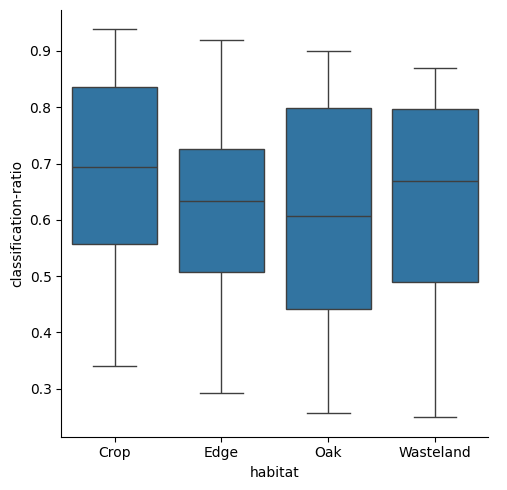

In [ ]:
g = sns.catplot(hits_classratio, x='habitat', y='classification-ratio', kind='box')

### Classification by domain

#### Domain read count and domain hits

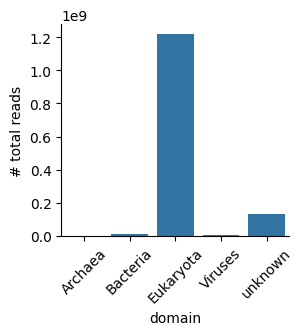

In [35]:
g = sns.catplot(
    x='domain', y='count', data=hits.groupby('domain')['count'].sum().reset_index().sort_values(by='domain'), 
    kind='bar', height=3.0
)
g.set_ylabels("# total reads")
g.set_xticklabels(rotation=45)

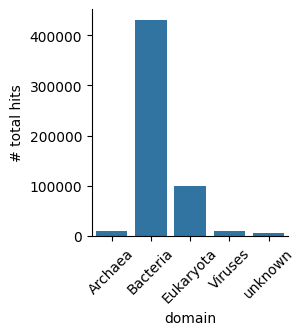

In [36]:
g = sns.catplot(
    x='domain', y='count', data=hits.value_counts(subset=['domain']).reset_index().sort_values(by='domain'),
    kind='bar', height=3.0
)
g.set_ylabels("# total hits")
g.set_xticklabels(rotation=45)

### Domain hit count by environment

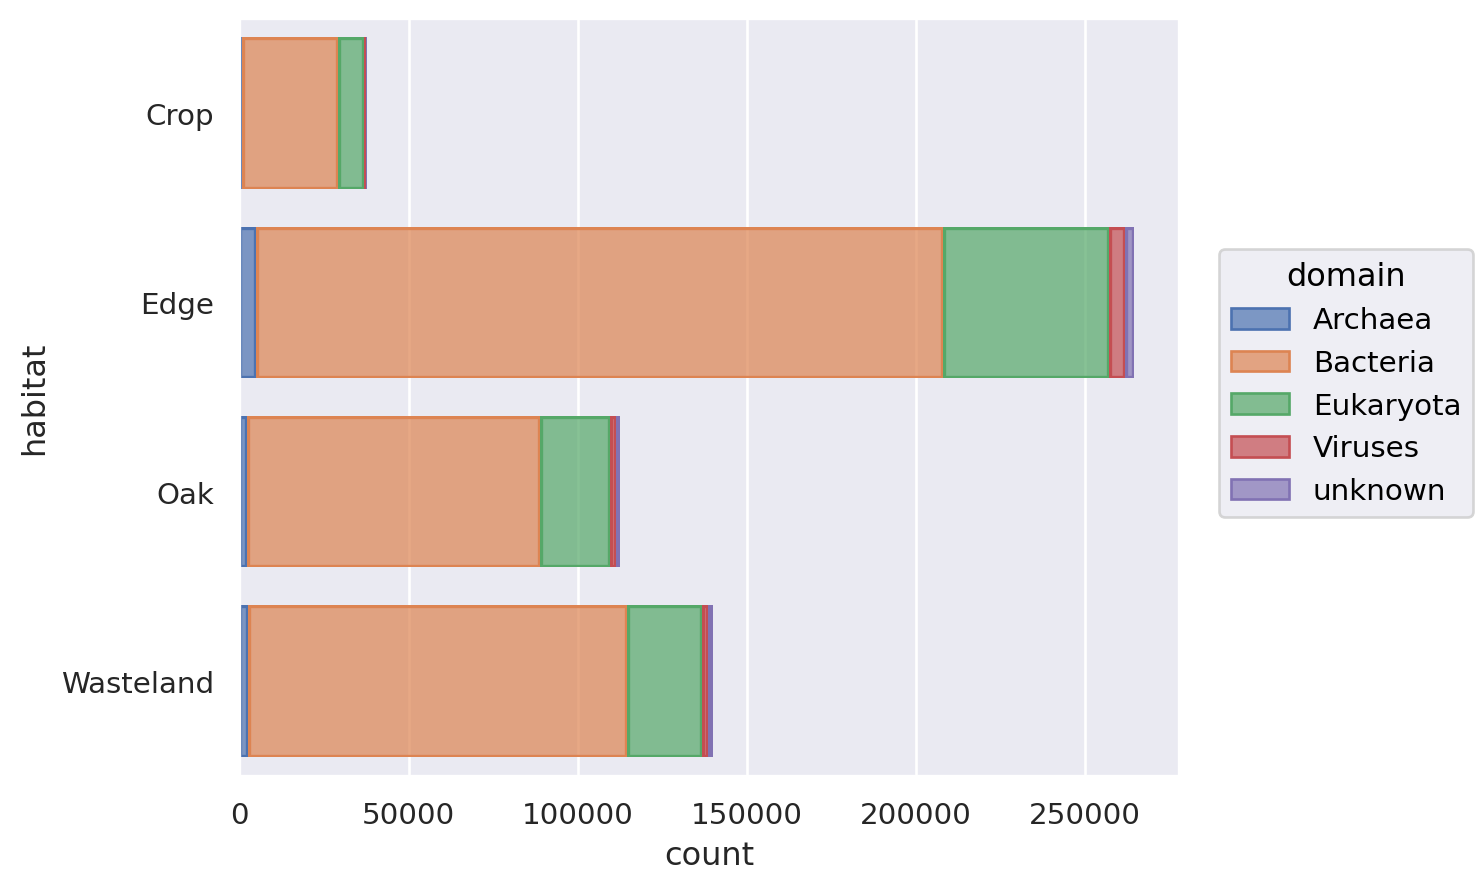

In [37]:

data=hits.value_counts(subset=['domain', 'habitat']).reset_index().sort_values(by=['domain', 'habitat'])

(
    so.Plot(
        data=data, 
        x="count", y="habitat", color="domain"
    ).add(
        so.Bar(), so.Stack()
    )
)

### Domain read count by environment

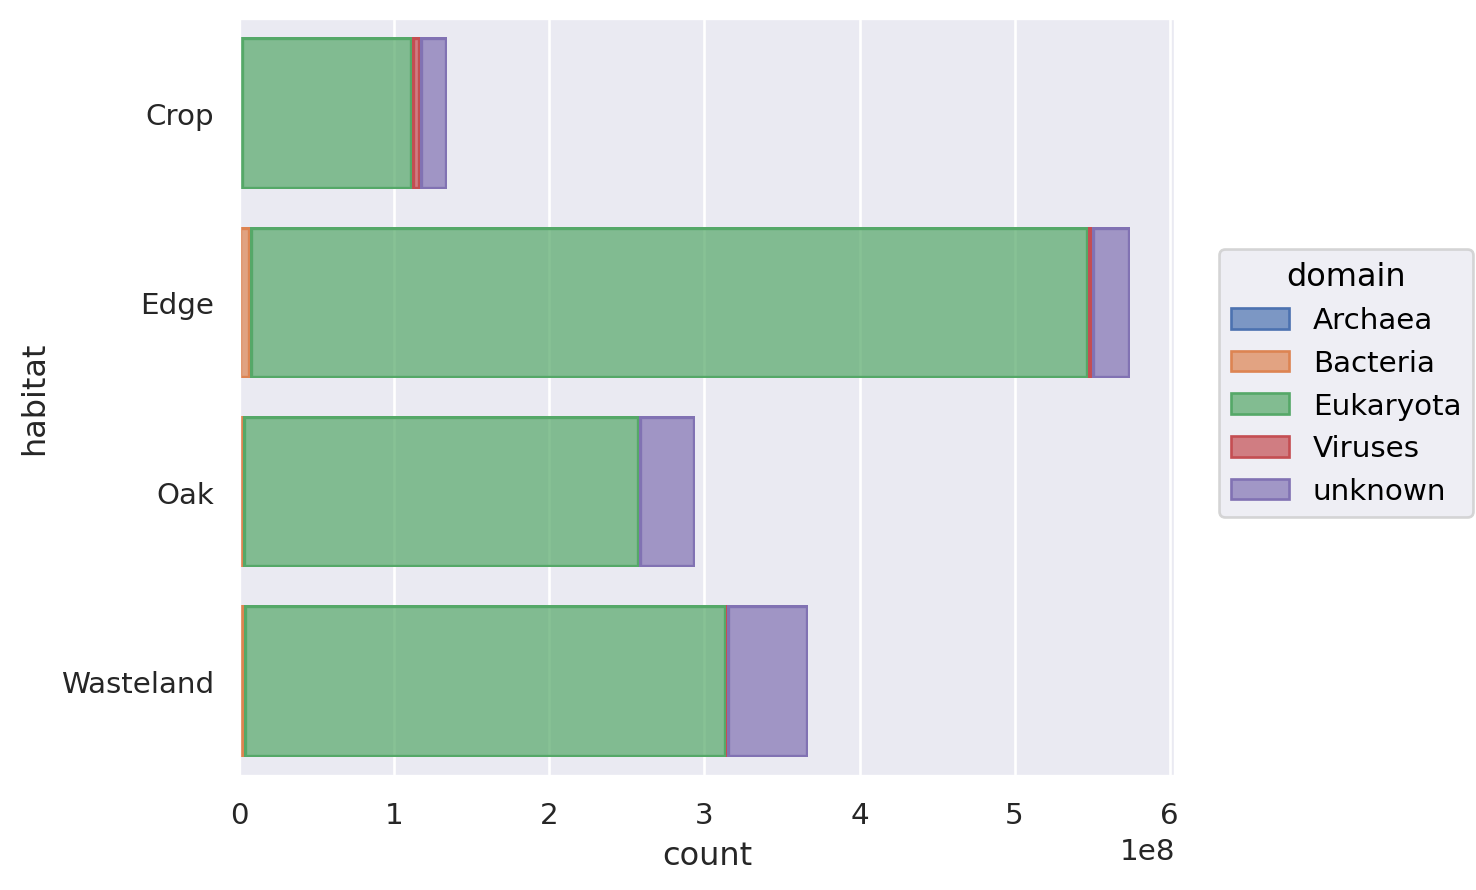

In [38]:

data=hits.groupby(by=['domain', 'habitat'])['count'].sum().reset_index().sort_values(by=['domain', 'habitat'])

(
    so.Plot(
        data=data, 
        x="count", y="habitat", color="domain"
    ).add(
        so.Bar(), so.Stack()
    )
)

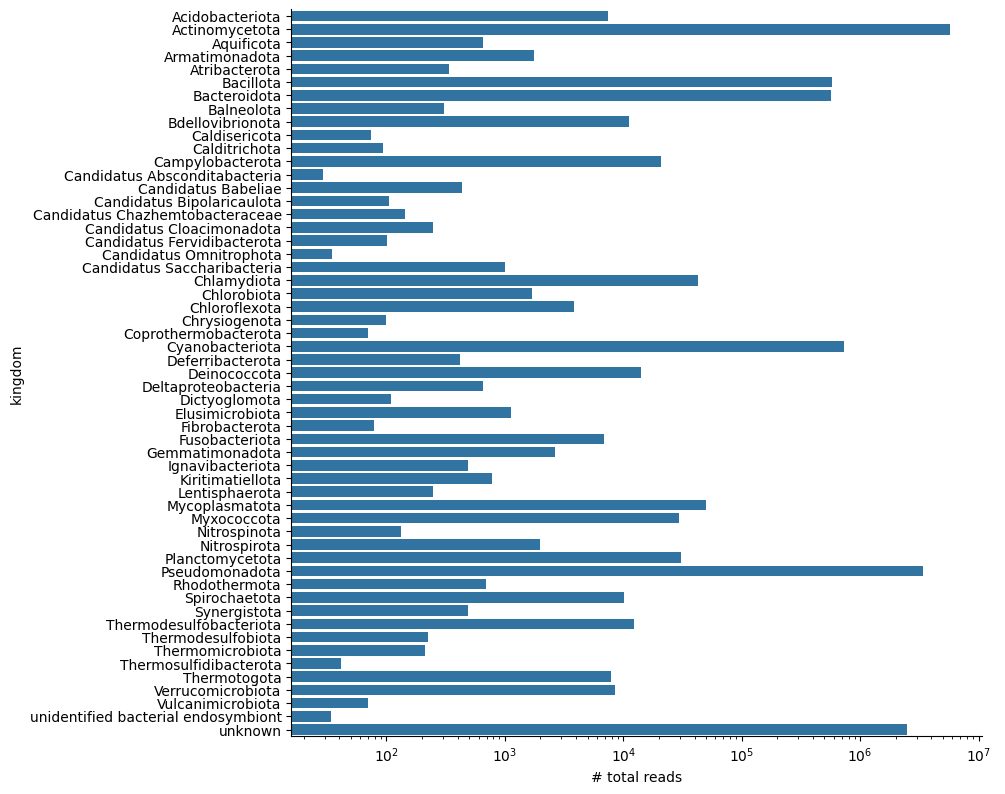

In [39]:
data = hits.query('domain == "Bacteria"').groupby('kingdom')['count'].sum().reset_index().sort_values(by='kingdom')
g = sns.catplot(
    y='kingdom', x='count', data=data, 
    kind='bar', height=8.0, aspect=1.25
)
g.set_xlabels("# total reads")
g.set_yticklabels(rotation=0)
g.axes[0, 0].set_xscale('log')

In [40]:
bacteria = hits.query('domain == "Bacteria"').copy()
kingdom10 = bacteria.query('kingdom != "unknown"').groupby(['kingdom'])['count'].sum().reset_index().sort_values(by='count', ascending=False)['kingdom'][:10].tolist()
bacteria['kingdom10'] = bacteria['kingdom'].apply(lambda x: x if x in kingdom10 else "Other")

In [41]:
bacteria

,library,classification-ratio,taxonid,scientific_name,count,domain,kingdom,phylum,class,order,family,genus,host_name,habitat,collection,n_extracts,kingdom10
24,PV051,0.849941,78331,Mycobacterium canetti,15259,Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Mycobacteriaceae,Mycobacterium,Mycobacterium canetti,Lotus corniculatus,Oak,Q4P,13.0,Actinomycetota
29,PV051,0.849941,2,Bacteria,8359,Bacteria,unknown,unknown,unknown,unknown,unknown,unknown,Lotus corniculatus,Oak,Q4P,13.0,Other
59,PV051,0.849941,1224,Pseudomonadota,2083,Bacteria,Pseudomonadota,unknown,unknown,unknown,unknown,unknown,Lotus corniculatus,Oak,Q4P,13.0,Pseudomonadota
157,PV051,0.849941,3028117,Cyanophyceae,235,Bacteria,Cyanobacteriota,Cyanophyceae,unknown,unknown,unknown,unknown,Lotus corniculatus,Oak,Q4P,13.0,Cyanobacteriota
169,PV051,0.849941,308865,Elizabethkingia,193,Bacteria,Bacteroidota,Flavobacteriia,Flavobacteriales,Weeksellaceae,Elizabethkingia,unknown,Lotus corniculatus,Oak,Q4P,13.0,Bacteroidota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554676,PV099,0.475667,157,Treponema,1,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponemataceae,Treponema,unknown,Anchusa undulata,Wasteland,E2F,13.0,Other
554677,PV099,0.475667,69,Lysobacter enzymogenes,1,Bacteria,Pseudomonadota,Gammaproteobacteria,Lysobacterales,Lysobacteraceae,Lysobacter,Lysobacter enzymogenes,Anchusa undulata,Wasteland,E2F,13.0,Pseudomonadota
554678,PV099,0.475667,34,Myxococcus xanthus,1,Bacteria,Myxococcota,Myxococcia,Myxococcales,Myxococcaceae,Myxococcus,Myxococcus xanthus,Anchusa undulata,Wasteland,E2F,13.0,Myxococcota
554679,PV099,0.475667,1798193,Erythrobacter sp. HL-111,1,Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Erythrobacteraceae,Erythrobacter,Erythrobacter sp. HL-111,Anchusa undulata,Wasteland,E2F,13.0,Pseudomonadota


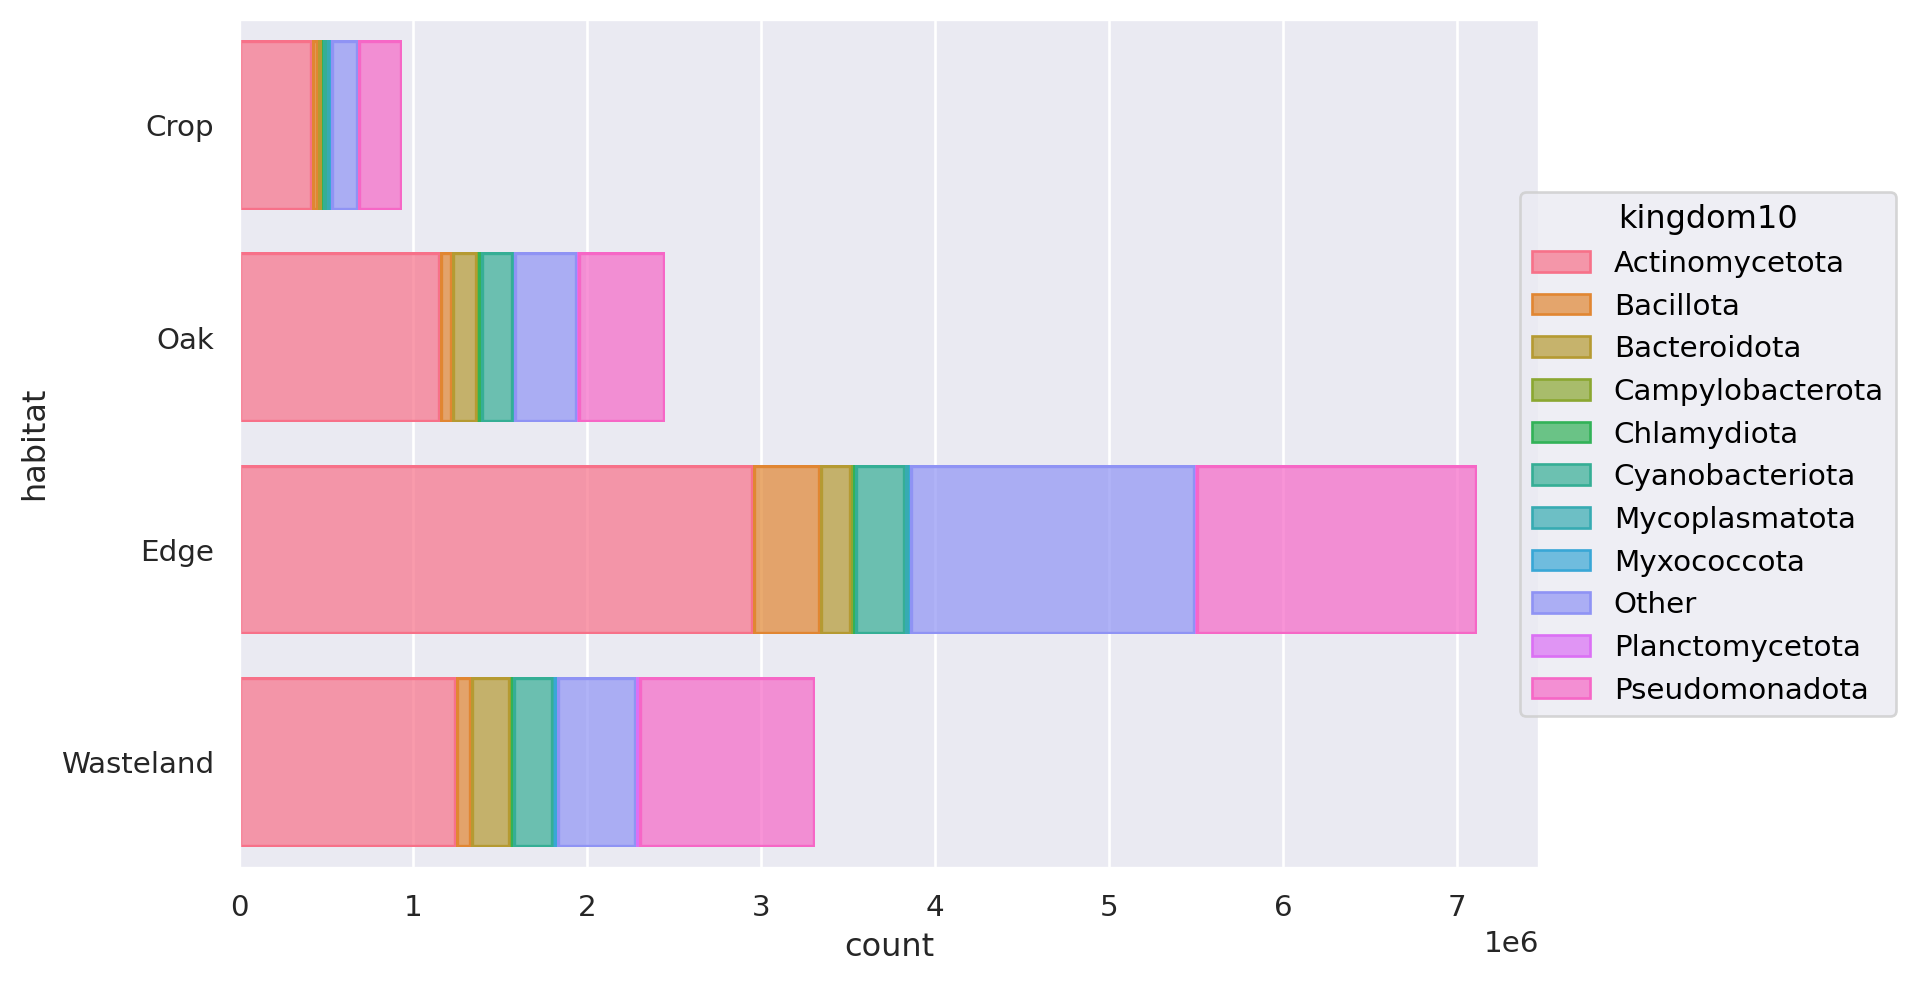

In [42]:

data=bacteria.groupby(['habitat', 'kingdom10'])['count'].sum().reset_index().sort_values(by='kingdom10')

(
    so.Plot(
        data=data, 
        x="count", y="habitat", color="kingdom10"
    ).add(
        so.Bar(), so.Stack()
    ).layout(
        size=(8,5), engine='constrained'
    )

)

In [43]:
bacteria_pvt = bacteria.groupby(['library', 'habitat', 'kingdom10'])['count'].apply(lambda x: np.log(x.sum() + 1)).reset_index().sort_values(by='kingdom10').pivot(index=['habitat', 'library'], columns='kingdom10', values='count').reset_index().fillna(0.0)

<Axes: xlabel='kingdom10'>

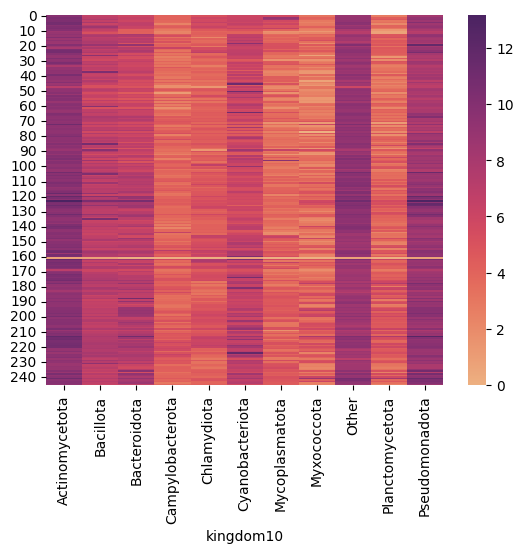

In [ ]:
columns = bacteria_pvt.columns[2:]

sns.heatmap(bacteria_pvt[columns], cmap='flare', )

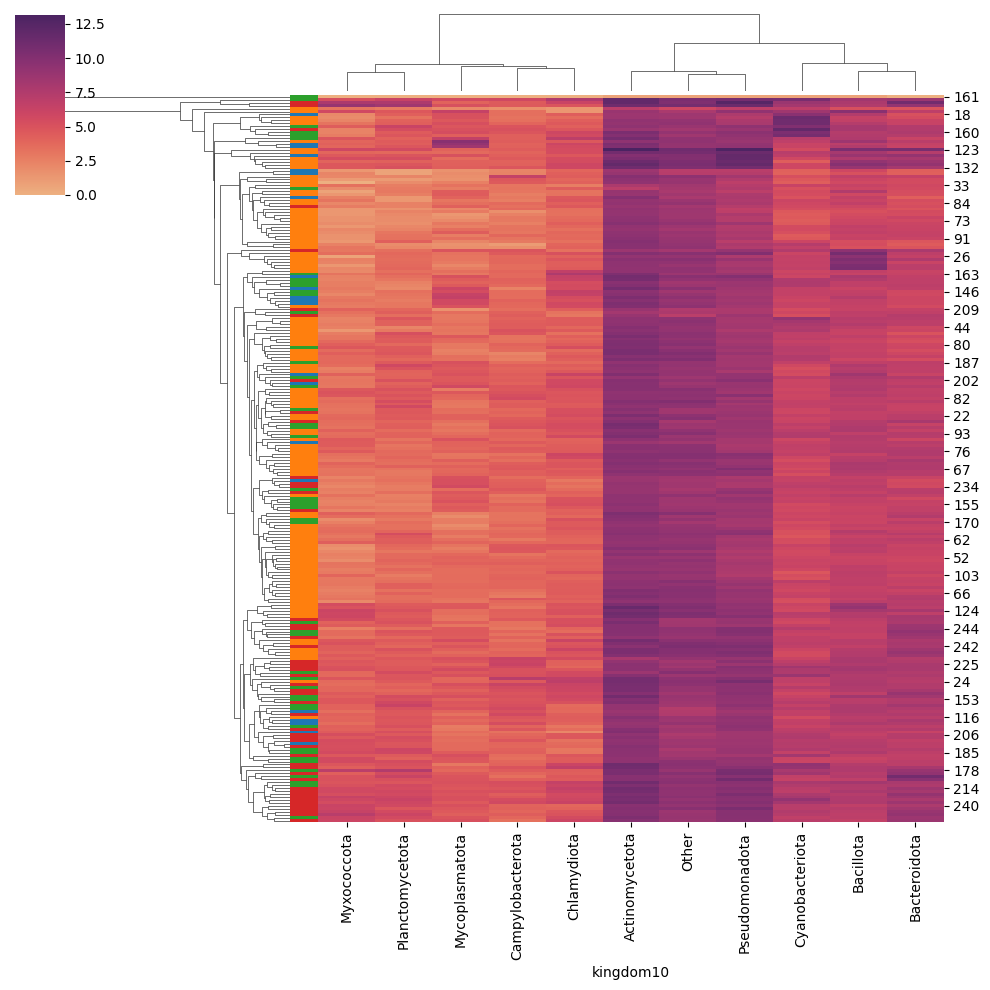

In [54]:
columns = bacteria_pvt.columns[2:]
palette = dict((key, color) for key, color in zip(['Crop', 'Edge', 'Oak', 'Wasteland'], sns.color_palette(n_colors=4)))
row_colors = [palette[item] for item in bacteria_pvt.habitat.to_list()]
sns.clustermap(bacteria_pvt[columns], cmap='flare', row_colors=row_colors, dendrogram_ratio=(0.3, 0.1))

In [56]:
bacteria_pvt = bacteria.groupby(['library', 'host_name', 'kingdom10'])['count'].apply(lambda x: np.log(x.sum() + 1)).reset_index().sort_values(by='kingdom10').pivot(index=['host_name', 'library'], columns='kingdom10', values='count').reset_index().fillna(0.0)

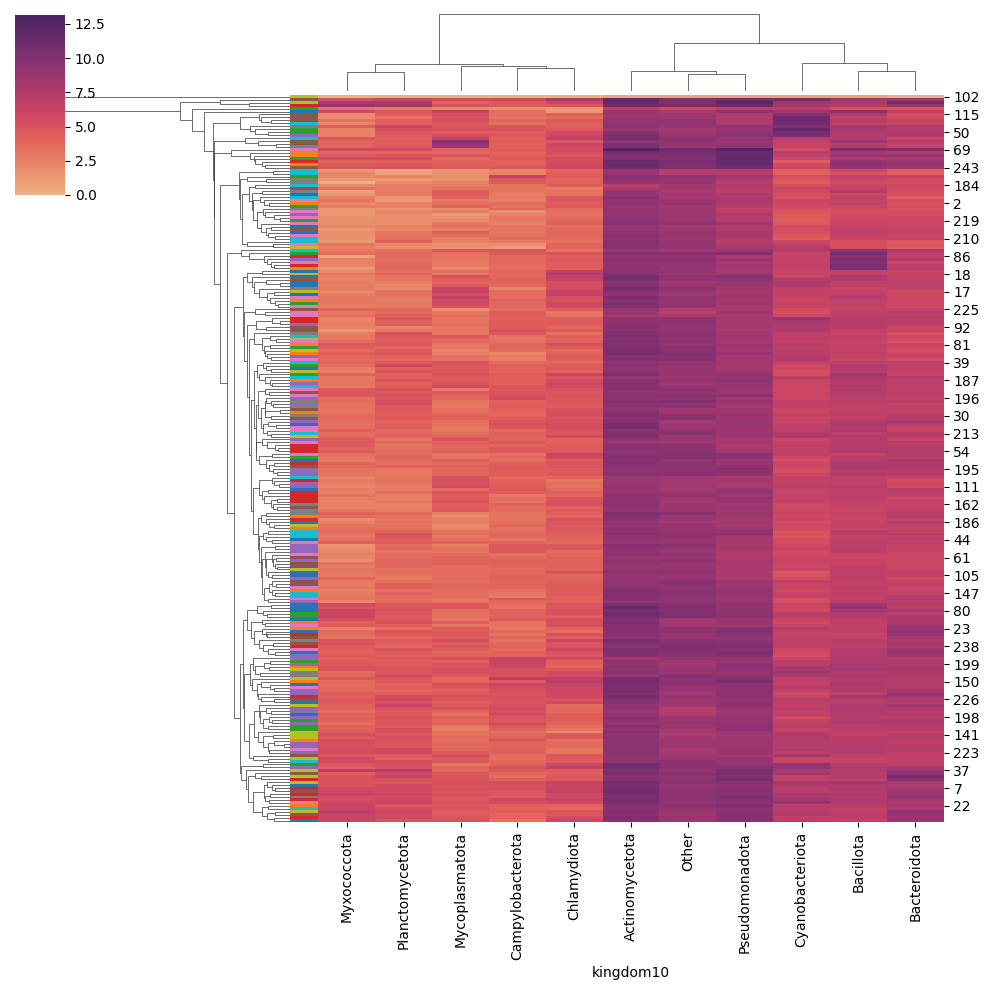

In [59]:

bacteria_list = bacteria_pvt.host_name.unique().tolist()
columns = bacteria_pvt.columns[2:]
palette = dict((key, color) for key, color in zip(bacteria_list, sns.color_palette(n_colors=len(bacteria_list))))
row_colors = [palette[item] for item in bacteria_pvt.host_name.to_list()]
sns.clustermap(bacteria_pvt[columns], cmap='flare', row_colors=row_colors, dendrogram_ratio=(0.3, 0.1))

### Host abundance

In [83]:
host_taxonomy = []
for name in tqdm.tqdm(hits.host_name.unique()):
    try:
        host_taxonomy.append(
            dict(taxon=taxoniq.Taxon(scientific_name=name), host_name=name)
        )
    except KeyError:
        pass 

100%|██████████| 108/108 [00:00<00:00, 48230.92it/s]


In [98]:
host_taxonomy = pd.DataFrame.from_records(host_taxonomy)
host_taxonomy['scientific_name'] = host_taxonomy['taxon'].apply(lambda x: x.scientific_name)
host_taxonomy['class'] = host_taxonomy['taxon'].apply(lambda x: list(reversed(x.ranked_lineage))[3].scientific_name)
host_taxonomy['phylum'] = host_taxonomy['taxon'].apply(lambda x: list(reversed(x.ranked_lineage))[2].scientific_name)
host_taxonomy

/tmp/ipykernel_714404/4167527863.py:1: FutureWarning: Passing a DataFrame to DataFrame.from_records is deprecated. Use set_index and/or drop to modify the DataFrame instead.
  host_taxonomy = pd.DataFrame.from_records(host_taxonomy)


,taxon,host_name,scientific_name,class,phylum
0,taxoniq.Taxon(47247),Lotus corniculatus,Lotus corniculatus,Magnoliopsida,Streptophyta
1,taxoniq.Taxon(1532285),Astragalus incanus,Astragalus incanus,Magnoliopsida,Streptophyta
2,taxoniq.Taxon(49992),Thymus vulgaris,Thymus vulgaris,Magnoliopsida,Streptophyta
3,taxoniq.Taxon(70962),Medicago orbicularis,Medicago orbicularis,Magnoliopsida,Streptophyta
4,taxoniq.Taxon(3656),Cucumis melo,Cucumis melo,Magnoliopsida,Streptophyta
...,...,...,...,...,...
76,taxoniq.Taxon(691781),Odontites luteus,Odontites luteus,Magnoliopsida,Streptophyta
77,taxoniq.Taxon(1117667),Teucrium capitatum,Teucrium capitatum,Magnoliopsida,Streptophyta
78,taxoniq.Taxon(83444),Avena sterilis,Avena sterilis,Magnoliopsida,Streptophyta
79,taxoniq.Taxon(1137014),Hypericum pubescens,Hypericum pubescens,Magnoliopsida,Streptophyta


In [111]:
hits_host_taxonomy = pd.merge(hits, host_taxonomy, left_on='host_name', right_on='host_name', how='inner')

In [112]:
hits_host_taxonomy['is_host_read_class'] = hits_host_taxonomy.apply(lambda x: x['class_x'] == x['class_y'], axis=1)
hits_host_taxonomy['is_host_read_phylum'] = hits_host_taxonomy.apply(lambda x: x['phylum_x'] == x['phylum_y'], axis=1)

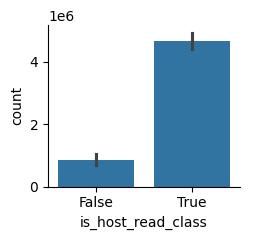

In [120]:
g = sns.catplot(
    data=hits_host_taxonomy.groupby(['library', 'is_host_read_class'], as_index=False)['count'].sum(),
    x='is_host_read_class', y='count', kind='bar', height=2.5
)
g.set_titles("host at class level")

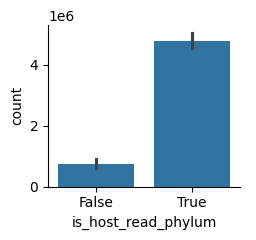

In [121]:
g = sns.catplot(
    data=hits_host_taxonomy.groupby(['library', 'is_host_read_phylum'], as_index=False)['count'].sum(),
    x='is_host_read_phylum', y='count', kind='bar', height=2.5
)
g.set_titles("host at class level")

In [115]:
hits_host_taxonomy.query('library == "PV054"')

,library,classification-ratio,taxonid,scientific_name_x,count,domain,kingdom,phylum_x,class_x,order,...,host_name,habitat,collection,n_extracts,taxon,scientific_name_y,class_y,phylum_y,is_host_read_class,is_host_read_phylum
4636,PV054,0.511443,21880,Salvia,888704,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,Lamiales,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,True,True
4637,PV054,0.511443,1437201,Pentapetalae,650240,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,True,True
4638,PV054,0.511443,1437183,Mesangiospermae,442669,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,True,True
4639,PV054,0.511443,91888,lamiids,434758,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,unknown,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,True,True
4640,PV054,0.511443,226208,Salvia miltiorrhiza,388311,Eukaryota,Viridiplantae,Streptophyta,Magnoliopsida,Lamiales,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7316,PV054,0.511443,1296669,Aquabacterium olei,1,Bacteria,Pseudomonadota,Betaproteobacteria,Burkholderiales,Aquabacterium,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,False,False
7317,PV054,0.511443,1295612,Mucilaginibacter yixingensis,1,Bacteria,Bacteroidota,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,False,False
7318,PV054,0.511443,1295534,Kwoniella dendrophila CBS 6074,1,Eukaryota,Fungi,Basidiomycota,Tremellomycetes,Tremellales,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,False,False
7319,PV054,0.511443,1325107,Bradyrhizobium zhanjiangense,1,Bacteria,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,...,Thymus vulgaris,Oak,Q4P,8.0,taxoniq.Taxon(49992),Thymus vulgaris,Magnoliopsida,Streptophyta,False,False


In [117]:
hits_host_taxonomy.value_counts(['library', 'is_host_read_phylum']).reset_index()

,library,is_host_read_phylum,count
0,PV215,False,8633
1,PV100,False,4911
2,PV217,False,4537
3,PV232,False,4529
4,PV216,False,4381
...,...,...,...
353,PV136,True,218
354,PV063,True,216
355,PV589,True,214
356,PV095,True,36


### Resolved species

In [149]:
bacteria['is_species'] = bacteria['taxonid'].apply(lambda x: ["F", "T"][taxoniq.Taxon(x).specified_species])

In [155]:
bacteria_species_resolved = bacteria.groupby(['library', 'is_species'], as_index=False)['count'].sum().pivot(index='library', columns='is_species', values='count')
bacteria_species_resolved['T_ratio'] = bacteria_species_resolved['T'] / (bacteria_species_resolved['T'] + bacteria_species_resolved['F'])

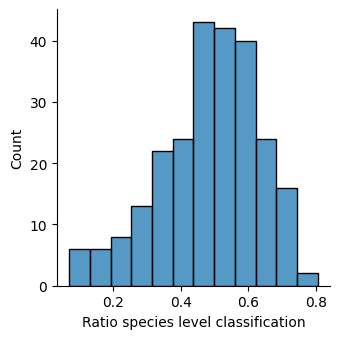

In [159]:
g = sns.displot(
    data=bacteria_species_resolved,
    x='T_ratio', height=3.5
)
g.set_xlabels("Ratio species level classification")


In [161]:
hits_classratio.sort_values(by='classification-ratio', ascending=False)

,habitat,library,classification-ratio
11,Crop,PV063,0.938131
10,Crop,PV062,0.920744
88,Edge,PV179,0.920033
51,Edge,PV141,0.915373
92,Edge,PV183,0.908618
...,...,...,...
21,Edge,PV028,0.305711
116,Edge,PV208,0.291846
217,Wasteland,PV087,0.262648
181,Oak,PV437,0.256723
